# Reasoning NCA: Inference & Visualization

Accompanying reproduction notebook to run inference and visualize step-by-step reasoning rollouts for trained NCA models on Maze and Sudoku benchmarks.

**Usage:** Select a runtime (GPU/TPU recommended), run the cells and upload checkpoint files (`config.json`, `ema_params.pickle`) to `checkpoints/<EXP_NAME>/` when prompted.

In [2]:
#@title installs

!pip install -q ml-collections
!pip install -q mediapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 70.5 MB/s eta 0:00:00


## reasoning_nca codebase

In [9]:
from jax.experimental.shard_map import shard_map

### dataset

In [10]:
#@title maze.py

import csv
import os
import pandas as pd
import pickle
import shutil
import urllib.request

from jax import jit, vmap
import jax.lax as lax
import jax.numpy as jnp
import jax.random as jr
import numpy as np

# =============================================================================
# Two vocabulary configurations are supported for Maze depending on whether endpoints
# share a common token (vocab=4) or are distinguished as source/target (vocab=5):
#
# Configuration 1: VOCAB_SIZE = 4, OUTPUT_EMB_D = 2
# +-------+--------------------+---------------+
# | Token | Semantic Meaning   | Embedding     |
# +-------+--------------------+---------------+
# |   0   | Empty cell         | [ 0, -1]      |
# |   1   | Solution path      | [ 0,  1]      |
# |   2   | Wall               | [ 1,  0]      |
# |   3   | Source / Target    | [-1,  0]      |
# +-------+--------------------+---------------+
#
# Configuration 2: VOCAB_SIZE = 5, OUTPUT_EMB_D = 3
# +-------+--------------------+---------------+
# | Token | Semantic Meaning   | Embedding     |
# +-------+--------------------+---------------+
# |   0   | Empty cell         | [ 0,  0,  0]  |
# |   1   | Solution path      | [ 0,  0,  1]  |
# |   2   | Wall               | [ 1,  0,  0]  |
# |   3   | Source endpoint    | [ 0, -1,  1]  |
# |   4   | Target endpoint    | [ 0,  1,  1]  |
# +-------+--------------------+---------------+
# =============================================================================

# ------------------------------------------------------------------------------
# Maze-OOD Dataset
# ------------------------------------------------------------------------------

def load_mood_dset(train_size=-1):
  dset = {}
  data_folder = "/content/dataset/Maze-OOD"
  if not os.path.exists(data_folder):
    os.makedirs(data_folder)
  train_fn = "maze_data_train_9"
  eval_fn = "maze_data_test_9"
  test_fn = "maze_data_test_15"

  for split, fn in zip(["train", "eval", "test"], [train_fn, eval_fn, test_fn]):
    fp = f"{data_folder}/{fn}"

    if not os.path.exists(fp):
      # download file from Easy_to_Hard_Datav2 url
      # adapted from https://github.com/aks2203/easy-to-hard-data/blob/main/easy_to_hard_data.py
      url = f"https://www.cs.umd.edu/~tomg/download/Easy_to_Hard_Datav2/{fn}.tar.gz"
      tar_path = f"{data_folder}/{fn}.tar.gz"
      urllib.request.urlretrieve(url, tar_path)
      shutil.unpack_archive(tar_path, data_folder)

    maze_inputs = np.load(f"{fp}/inputs.npy").astype(np.int8).transpose(0, 2, 3, 1)
    maze_inputs = maze_inputs[:, 1:-1:2, 1:-1:2]
    maze_targets = np.load(f"{fp}/solutions.npy").astype(np.int8)
    maze_targets = maze_targets[:, 1:-1:2, 1:-1:2]

    if split == "train" and train_size > 0:
      maze_inputs = maze_inputs[:train_size]
      maze_targets = maze_targets[:train_size]

    inputs = np.zeros(maze_inputs.shape[:-1], dtype=np.uint8)
    # wall
    inputs[(maze_inputs[..., 0] + maze_inputs[..., 1]) == 0] = 2
    # source/target
    inputs[(maze_inputs[..., 0] - maze_inputs[..., 2]) > 0] = 3
    inputs[(maze_inputs[..., 1] - maze_inputs[..., 2]) > 0] = 3

    targets = inputs.copy()
    # solution path (does not include source/target)
    targets[maze_targets == 1 & (inputs < 3)] = 1
    input_masks = inputs > 0
    difficulties = (targets == 1).sum(-1).sum(-1)

    dset[split] = {
        "input_masks": input_masks,
        "input_grids": inputs,
        "target_grids": targets,
        "difficulties": difficulties,
    }
  return dset


def load_mood_test_dset():
  dset = {}
  data_folder = "/content/dataset/Maze-OOD/"
  if not os.path.exists(data_folder):
    os.makedirs(data_folder)

  for grid_size in np.arange(9, 37+1, 2).tolist() + [59, 201]:
    fn = f"maze_data_test_{grid_size}"
    fp = f"{data_folder}/{fn}"

    if not os.path.exists(fp):
      # download file from Easy_to_Hard_Datav2 url
      # adapted from https://github.com/aks2203/easy-to-hard-data/blob/main/easy_to_hard_data.py
      url = f"https://www.cs.umd.edu/~tomg/download/Easy_to_Hard_Datav2/{fn}.tar.gz"
      tar_path = f"{data_folder}/{fn}.tar.gz"
      urllib.request.urlretrieve(url, tar_path)
      shutil.unpack_archive(tar_path, data_folder)

    maze_inputs = np.load(f"{fp}/inputs.npy").astype(np.int8).transpose(0, 2, 3, 1)
    maze_inputs = maze_inputs[:, 1:-1:2, 1:-1:2]
    maze_targets = np.load(f"{fp}/solutions.npy").astype(np.int8)
    maze_targets = maze_targets[:, 1:-1:2, 1:-1:2]

    inputs = np.zeros(maze_inputs.shape[:-1], dtype=np.uint8)
    # wall
    inputs[(maze_inputs[..., 0] + maze_inputs[..., 1]) == 0] = 2
    # source/target
    inputs[(maze_inputs[..., 0] - maze_inputs[..., 2]) > 0] = 3
    inputs[(maze_inputs[..., 1] - maze_inputs[..., 2]) > 0] = 3

    targets = inputs.copy()
    # solution path (does not include source/target)
    targets[maze_targets == 1 & (inputs < 3)] = 1
    input_masks = inputs > 0
    difficulties = (targets == 1).sum(-1).sum(-1)

    dset[grid_size] = {
        "input_masks": input_masks,
        "input_grids": inputs,
        "target_grids": targets,
        "difficulties": difficulties,
    }
  return dset


# ------------------------------------------------------------------------------
# Maze-Hard Dataset
# ------------------------------------------------------------------------------


def parse_mhard_csv(url_or_path):
  df = pd.read_csv(url_or_path)
  inputs, targets, difficulties = [], [], []
  for _, row in df.iterrows():
    q, a, rating = str(row["question"]), str(row["answer"]), int(row["rating"])
    input = np.zeros((30, 30), dtype=np.uint8)
    q = np.frombuffer(q.encode(), dtype=np.uint8).reshape(30, 30)
    a = np.frombuffer(a.encode(), dtype=np.uint8).reshape(30, 30)
    input[q == ord("#")] = 2  # walls
    input[q == ord("S")] = 3  # source
    input[q == ord("G")] = 4  # target
    target = input.copy()
    target[a == ord("o")] = 1  # solution

    inputs.append(input)
    targets.append(target)
    difficulties.append(int(rating))

  inputs_np = np.array(inputs, dtype=np.uint8)
  input_masks = (inputs_np > 0).astype(bool)
  targets_np = np.array(targets, dtype=np.uint8)
  difficulties_np = np.array(difficulties, dtype=np.uint16)
  return {
      "input_masks": input_masks,
      "input_grids": (input_masks * targets_np).astype(np.uint8),
      "target_grids": targets_np,
      "difficulties": difficulties_np,
  }


def load_mhard_dset(train_size=-1):
  hard_url = f"https://huggingface.co/datasets/sapientinc/maze-30x30-hard-1k/resolve/main"
  train = parse_mhard_csv(f"{hard_url}/train.csv")
  test = parse_mhard_csv(f"{hard_url}/test.csv")
  if train_size > 0:
    train = {k: v[:train_size] for k, v in train.items()}

  dset = {
      "train": train,
      "eval": train, #No eval set so we use train set
      "test": test,
  }

  return dset


def load_mhard_test_dset():
  hard_url = f"https://huggingface.co/datasets/sapientinc/maze-30x30-hard-1k/resolve/main"
  test = parse_mhard_csv(f"{hard_url}/test.csv")
  dset = {
      "hard": test,
  }
  return dset

# ------------------------------------------------------------------------------
# Dihedral augmentations
# ------------------------------------------------------------------------------

@jit
def maze_augment_grids(key, input_masks, target_grids):
  """Applies random augmentation to input masks and target grids."""

  # 8 possible augmentations (identity, 3 rotations, 4 reflections)
  tid = jr.randint(key, shape=(), minval=0, maxval=8)

  def f0(operands):  # identity
    im, tg = operands
    return im, tg

  def f1(operands):  # rot90
    im, tg = operands
    return jnp.rot90(im, k=1, axes=(1, 2)), jnp.rot90(tg, k=1, axes=(1, 2))

  def f2(operands):  # rot180
    im, tg = operands
    return jnp.rot90(im, k=2, axes=(1, 2)), jnp.rot90(tg, k=2, axes=(1, 2))

  def f3(operands):  # rot270
    im, tg = operands
    return jnp.rot90(im, k=3, axes=(1, 2)), jnp.rot90(tg, k=3, axes=(1, 2))

  def f4(operands):  # flip horizontal
    im, tg = operands
    return jnp.flip(im, axis=2), jnp.flip(tg, axis=2)

  def f5(operands):  # flip vertical
    im, tg = operands
    return jnp.flip(im, axis=1), jnp.flip(tg, axis=1)

  def f6(operands):  # transpose
    im, tg = operands
    return im.swapaxes(1, 2), tg.swapaxes(1, 2)

  def f7(operands):  # anti-diagonal reflection
    im, tg = operands
    return jnp.flip(jnp.rot90(im, k=1, axes=(1, 2)), axis=2), jnp.flip(
        jnp.rot90(tg, k=1, axes=(1, 2)), axis=2
    )

  branches = [f0, f1, f2, f3, f4, f5, f6, f7]

  input_masks, target_grids = lax.switch(
      tid,
      branches,
      (input_masks, target_grids),
  )
  return input_masks, target_grids


# ------------------------------------------------------------------------------
# Pathfinding functions
# Adapted from https://github.com/smearle/pcgrl-jax/blob/main/envs/pathfinding.py
# ------------------------------------------------------------------------------


def flood_init(input_grid):
  source_target_pos = jnp.argwhere(input_grid >= 3, size=2)
  source_pos = source_target_pos[0]
  target_pos = source_target_pos[1]

  flood_count = jnp.zeros_like(input_grid, dtype=jnp.uint8)
  flood_count = flood_count.at[source_pos[0], source_pos[1]].set(1)

  occupied_map = (input_grid == 2).astype(jnp.float32)
  flood_arr = jnp.stack(
      [occupied_map, flood_count.astype(jnp.float32)], axis=-1
  )

  has_reached_trg = (source_pos == target_pos).all()
  flood_state = (flood_arr, flood_count, target_pos, has_reached_trg, False)
  return flood_state


# Build a static kernel with shape (3, 3, in_ch=2, out_ch=1)
flood_kernel = np.zeros((3, 3, 2, 1), dtype=np.float32)
# Walls on center tile prevent it from being flooded (input channel 0 is occupied_map)
flood_kernel[1, 1, 0, 0] = -5
# Flood at adjacent tile produces flood toward center tile (input channel 1 is flood)
flood_kernel[1, 2, 1, 0] = 1
flood_kernel[2, 1, 1, 0] = 1
flood_kernel[1, 0, 1, 0] = 1
flood_kernel[0, 1, 1, 0] = 1
flood_kernel[1, 1, 1, 0] = 1


def flood_conv(flood_input):
  # Add batch dim to match NHWC expected by lax conv, then remove it after.
  flood_output = lax.conv_general_dilated(
      lhs=flood_input[None],
      rhs=flood_kernel,
      window_strides=(1, 1),
      padding="SAME",
      dimension_numbers=("NHWC", "HWIO", "NCHW"),
  )[0, 0]

  return flood_output


def flood_step(flood_state):
  flood_input, flood_count, target_pos, has_reached_trg, no_change = flood_state
  flood_out = flood_conv(flood_input)
  flood_out = jnp.clip(flood_out, min=0,         max=1)
  flood_arr = jnp.stack([flood_input[:, :, 0], flood_out], axis=-1)
  flood_count = flood_out.astype(jnp.uint8) + flood_count
  has_reached_trg = flood_count[target_pos[0], target_pos[1]] > 0
  no_change = jnp.all(flood_input[:, :, 1] == flood_out)
  flood_state = (flood_arr, flood_count, target_pos, has_reached_trg, no_change)
  return flood_state


def pathextraction_init(flood_count, target_pos, max_path_len=1000):
  path_coords = jnp.full((max_path_len, 2), fill_value=-1, dtype=jnp.int32)
  path_coords = path_coords.at[0].set((target_pos[0], target_pos[1]))
  curr_val = flood_count[target_pos[0], target_pos[1]].astype(jnp.int32)
  flood_count = jnp.where(
      flood_count == 0, 999999, flood_count.astype(jnp.int32)
  )
  padded_flood_count = jnp.pad(
      flood_count, 1, mode="constant", constant_values=999999
  )

  pathextraction_state = (curr_val, path_coords, padded_flood_count, 0)
  return pathextraction_state


def pathextraction_step(pathextraction_state):
  # Get the coordinates of a neighbor tile where the count is curr_val + 1
  curr_val, path_coords, padded_flood_count, i = pathextraction_state
  last_yx = path_coords[i]
  padded_flood_count = padded_flood_count.at[
      last_yx[0] + 1, last_yx[1] + 1
  ].set(999999)
  nb_slice = lax.dynamic_slice(
      padded_flood_count, (last_yx[0], last_yx[1]), (3, 3)
  )
  # Mask out the corners to prevent diagonal movement
  nb_slice = nb_slice.at[[0, 0, 2, 2], [0, 2, 0, 2]].set(999999)
  # Get the coordinates of the minimum value
  # with priority tlrb as we always select the first result of argwhere
  y, x = jnp.argwhere(nb_slice == curr_val + 1, size=1, fill_value=-1)[0]
  y, x = y - 1, x - 1
  yx = last_yx + jnp.array([y, x], dtype=jnp.int32)
  path_coords = path_coords.at[i + 1].set(yx)

  pathextraction_state = (curr_val + 1, path_coords, padded_flood_count, i + 1)
  return pathextraction_state


@jit
def pathfinding(input_grid):
  # flooding
  flood_state = flood_init(input_grid)
  flood_state = lax.while_loop(
      lambda fs: jnp.logical_and(
          jnp.logical_not(fs[-1]), jnp.logical_not(fs[-2])
      ),
      flood_step,
      flood_state,
  )
  is_solution = flood_state[-2]

  # path extraction
  _, flood_count, target_pos, _, _ = flood_state
  pathextraction_state = pathextraction_init(flood_count, target_pos)
  max_val = jnp.max(flood_count)
  pathextraction_state = lax.while_loop(
      lambda pes: pes[0] < max_val, pathextraction_step, pathextraction_state
  )
  path_coords = pathextraction_state[1]
  solution = jnp.zeros(flood_count.shape, dtype=jnp.bool_)
  solution = jnp.pad(solution, 1, mode="constant", constant_values=False)
  solution = solution.at[path_coords[:, 0] + 1, path_coords[:, 1] + 1].set(True)
  solution = solution[1:-1, 1:-1]

  solution_grid = jnp.where(solution, 1, input_grid)
  solution_grid = jnp.where(input_grid == 3, 3, solution_grid)
  solution_grid = jnp.where(input_grid == 4, 4, solution_grid)

  return is_solution, solution_grid


# ------------------------------------------------------------------------------
# Check path validity functions
# Assumes correct input wall token 2, source token 3, and target token 3 or 4
# ------------------------------------------------------------------------------


def isvalid_init(pred_grid, max_path_len=1000):
  source_target_pos = jnp.argwhere(pred_grid >= 3, size=2)
  source_pos = source_target_pos[0]
  target_pos = source_target_pos[1]

  solution = (pred_grid == 1) | (pred_grid >= 3)

  source_pred = lax.dynamic_slice(
      solution, (source_pos[0], source_pos[1]), (1, 1)
  )[0, 0]
  target_pred = lax.dynamic_slice(
      solution, (target_pos[0], target_pos[1]), (1, 1)
  )[0, 0]
  is_valid = jnp.logical_and(source_pred, target_pred)
  done = jnp.logical_or(
      jnp.logical_not(is_valid), (source_pos == target_pos).all()
  )

  path_coords = jnp.pad(
      source_pos[None, :], ((0, max_path_len - 1), (0, 0)), constant_values=-1
  )

  padded_solution = jnp.pad(solution, 1, mode="constant", constant_values=False)
  isvalid_state = (path_coords, padded_solution, target_pos, is_valid, done, 0)
  return isvalid_state


def isvalid_step(isvalid_state):
  # Get the coordinates of an active neighbor tile on solution path
  path_coords, padded_solution, target_pos, is_valid, done, i = isvalid_state
  last_yx = path_coords[i]
  padded_solution = padded_solution.at[last_yx[0] + 1, last_yx[1] + 1].set(
      False
  )
  nb_slice = lax.dynamic_slice(
      padded_solution, (last_yx[0], last_yx[1]), (3, 3)
  )
  # Mask out the corners to not count diagonal movement
  nb_slice = nb_slice.at[[0, 0, 2, 2], [0, 2, 0, 2]].set(False)
  # Get the number of active values on path
  is_valid = nb_slice.sum() == 1  # assert than only one neighbor is valid
  y, x = jnp.argwhere(nb_slice, size=1, fill_value=-1)[0]
  y, x = y - 1, x - 1
  yx = last_yx + jnp.array([y, x], dtype=jnp.int32)
  path_coords = path_coords.at[i + 1].set(yx)
  done = jnp.logical_or(jnp.logical_not(is_valid), (yx == target_pos).all())
  isvalid_state = (
      path_coords,
      padded_solution,
      target_pos,
      is_valid,
      done,
      i + 1,
  )
  return isvalid_state


def isvalid_solution(pred_grid, max_path_len=100):
  isvalid_state = isvalid_init(pred_grid, max_path_len=max_path_len)

  isvalid_state = lax.while_loop(
      lambda ivs: jnp.logical_not(ivs[-2]), isvalid_step, isvalid_state
  )
  exists_valid_path = isvalid_state[-3]
  padded_solution = isvalid_state[1]
  false_positives = padded_solution.sum() - 1
  is_valid = jnp.logical_and(exists_valid_path, false_positives == 0)
  return is_valid


b_isvalid_solution = vmap(isvalid_solution, in_axes=(0, None), out_axes=0)


In [11]:
#@title sudoku.py
import os
import pandas as pd
import pickle
import shutil
import urllib.request

from jax import jit
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import torch

# ------------------------------------------------------------------------------
# Sudoku-OOD Dataset
# ------------------------------------------------------------------------------

def load_sood_dset(train_size=-1):
  dset = {}
  data_folder = "/content/dataset/Sudoku-OOD"
  if not os.path.exists(data_folder):
    os.makedirs(data_folder)
  easy_url = "https://powei.tw/sudoku.zip"
  hard_url = "https://www.dropbox.com/s/rp3hbjs91xiqdgc/sudoku-hard.zip?dl=1"

  input_path = f"{data_folder}/sudoku/features.pt"
  if not os.path.exists(input_path):
    # download file from original SAT-Net repo
    # adapted from https://github.com/autonomousvision/akorn/blob/main/data/download_satnet.sh
    zip_path = f"{data_folder}/sudoku.zip"
    urllib.request.urlretrieve(easy_url, zip_path)
    shutil.unpack_archive(zip_path, data_folder)

  inputs = torch.load(input_path, map_location="cpu").numpy()
  input_masks = inputs.sum(-1)  # 1 for prefilled cells, O for empty cells
  target_path = f"{data_folder}/sudoku/labels.pt"
  targets = torch.load(target_path, map_location="cpu").numpy()

  for split, ids in zip(["train", "eval"], [np.r_[0:9000], np.r_[9000:10000]]):
    input_masks_split = input_masks[ids]
    targets_split = targets[ids].argmax(-1) + 1

    if split == "train" and train_size > 0:
      input_masks_split = input_masks_split[:train_size]
      targets_split = targets_split[:train_size]

    input_masks_split = input_masks_split.astype(np.bool)
    targets_split = targets_split.astype(np.uint8)
    inputs_split = input_masks_split * targets_split
    difficulties_split = 81 - input_masks_split.sum(-1).sum(-1)
    dset[split] = {
        "input_masks": input_masks_split,
        "input_grids": inputs_split,
        "target_grids": targets_split,
        "difficulties": difficulties_split,
    }


  test_path = f"{data_folder}/sudoku-hard/test.csv"
  if not os.path.exists(test_path):
    # download file from original  RRN Sodoku data
    # adapted from https://github.com/autonomousvision/akorn/blob/main/data/download_rrn.sh
    zip_path = f"{data_folder}/sudoku-hard.zip"
    urllib.request.urlretrieve(hard_url, zip_path)
    shutil.unpack_archive(zip_path, data_folder)

  test_df = pd.read_csv(test_path, header=None)
  input_masks = np.zeros((len(test_df), 9, 9), dtype=np.uint8)
  targets = np.zeros((len(test_df), 9, 9), dtype=np.uint8)
  for i in range(len(test_df)):
    input_masks[i] = np.array(
        [int(j) > 0 for j in test_df.iloc[i][0]], dtype=np.uint8
    ).reshape(9, 9)
    targets[i] = np.array(
        [int(j) for j in test_df.iloc[i][1]], dtype=np.uint8
    ).reshape(9, 9)

  input_masks = input_masks.astype(np.bool)
  targets = targets.astype(np.uint8)
  inputs = input_masks * targets
  difficulties = 81 - input_masks.sum(-1).sum(-1)

  dset["test"] = {
      "input_masks": input_masks,
      "input_grids": inputs,
      "target_grids": targets,
      "difficulties": difficulties,
  }

  return dset


def load_sood_test_dset():
  dset = {}
  data_folder = "/content/dataset/Sudoku-OOD"
  if not os.path.exists(data_folder):
    os.makedirs(data_folder)
  hard_url = "https://www.dropbox.com/s/rp3hbjs91xiqdgc/sudoku-hard.zip?dl=1"

  test_path = f"{data_folder}/sudoku-hard/test.csv"
  if not os.path.exists(test_path):
    # download file from original  RRN Sodoku data
    # adapted from https://github.com/autonomousvision/akorn/blob/main/data/download_rrn.sh
    zip_path = f"{data_folder}/sudoku-hard.zip"
    urllib.request.urlretrieve(hard_url, zip_path)
    shutil.unpack_archive(zip_path, data_folder)

  test_df = pd.read_csv(test_path, header=None)
  input_masks = np.zeros((len(test_df), 9, 9), dtype=np.uint8)
  targets = np.zeros((len(test_df), 9, 9), dtype=np.uint8)
  for i in range(len(test_df)):
    input_masks[i] = np.array(
        [int(j) > 0 for j in test_df.iloc[i][0]], dtype=np.uint8
    ).reshape(9, 9)
    targets[i] = np.array(
        [int(j) for j in test_df.iloc[i][1]], dtype=np.uint8
    ).reshape(9, 9)

  input_masks = input_masks.astype(np.bool)
  targets = targets.astype(np.uint8)
  inputs = input_masks * targets
  difficulties = 81 - input_masks.sum(-1).sum(-1)

  unique_difficulties = np.unique(difficulties)
  for d in unique_difficulties:
    dset[d] = {
        "input_masks": input_masks[difficulties == d],
        "input_grids": inputs[difficulties == d],
        "target_grids": targets[difficulties == d],
        "difficulties": difficulties[difficulties == d],
    }

  return dset

# ------------------------------------------------------------------------------
# Sudoku-Extreme Dataset
# ------------------------------------------------------------------------------

def parse_sext_csv(url_or_path, indices=None):
  df = pd.read_csv(url_or_path)
  inputs, targets, difficulties = [], [], []
  sub_df = df if indices is None else df.iloc[indices]
  for _, row in sub_df.iterrows():
    q = str(row["question"])
    a = str(row["answer"])
    inputs.append(
        np.frombuffer(q.replace(".", "0").encode(), dtype=np.uint8).reshape(9, 9)
        - ord("0")
    )
    targets.append(
        np.frombuffer(a.encode(), dtype=np.uint8).reshape(9, 9) - ord("0")
    )
    difficulties.append(int(row["rating"]))

  inputs_np = np.array(inputs, dtype=np.uint8)
  input_masks = (inputs_np > 0).astype(bool)
  targets_np = np.array(targets, dtype=np.uint8)
  difficulties_np = np.array(difficulties, dtype=np.uint16)
  return {
      "input_masks": input_masks,
      "input_grids": (input_masks * targets_np).astype(np.uint8),
      "target_grids": targets_np,
      "difficulties": difficulties_np,
  }

def load_sext_dset(train_size=-1):
  url_sext = "https://huggingface.co/datasets/sapientinc/sudoku-extreme/resolve/main"
  n = 3831994
  if train_size < 0 or train_size > n:
    train_size = n
  eval_size = train_size // 5

  rng = np.random.RandomState(0)
  perm = rng.permutation(n)
  train_indices = perm[:train_size]
  eval_indices = perm[n - eval_size:]

  dset = {
      "train": parse_sext_csv(f"{url_sext}/train.csv", train_indices),
      "eval": parse_sext_csv(f"{url_sext}/train.csv", eval_indices),
      "test": parse_sext_csv(f"{url_sext}/test.csv"),
  }
  return dset

def load_sext_test_dset():
  url_sext = "https://huggingface.co/datasets/sapientinc/sudoku-extreme/resolve/main"
  parsed = parse_sext_csv(f"{url_sext}/test.csv")
  inputs = parsed["input_grids"]
  input_masks = parsed["input_masks"]
  targets = parsed["target_grids"]
  difficulties = parsed["difficulties"]

  dset = {}
  difficulty_bin_edges = [0, 1, 2, 6, 11, 16, 21, 27, 33, 42, 54, 289 + 1]
  for bin_left, bin_right in zip(
      difficulty_bin_edges[:-1], difficulty_bin_edges[1:]
  ):
    in_bin = np.logical_and(difficulties >= bin_left, difficulties < bin_right)
    bin_inputs = inputs[in_bin]
    bin_input_masks = input_masks[in_bin]
    bin_targets = targets[in_bin]
    bin_diffs = difficulties[in_bin]

    n_examples = len(bin_inputs)
    n_sub_bins = max(1, (n_examples + 9999) // 10000)
    for i in range(n_sub_bins):
      suffix = ""
      temp = i
      while True:
        suffix = chr(ord("a") + (temp % 26)) + suffix
        temp = temp // 26 - 1
        if temp < 0:
          break
      d = f"{int(bin_left)}-{int(bin_right)}-{suffix}"
      start_idx = i * 10000
      end_idx = min((i + 1) * 10000, n_examples)
      dset[d] = {
          "input_grids": bin_inputs[start_idx:end_idx],
          "input_masks": bin_input_masks[start_idx:end_idx],
          "target_grids": bin_targets[start_idx:end_idx],
          "difficulties": bin_diffs[start_idx:end_idx],
      }

  return dset

# ------------------------------------------------------------------------------
# Sudoku Valid Augmentations
# ------------------------------------------------------------------------------


@jit
def sudoku_augment_grids(key, input_masks, target_grids):

  # transpose permutation
  k1, key = jr.split(key)
  is_transpose = jr.bernoulli(k1, p=0.5)
  input_masks = (
      is_transpose * jnp.transpose(input_masks, (0, 2, 1))
      + (1 - is_transpose) * input_masks
  )
  target_grids = (
      is_transpose * jnp.transpose(target_grids, (0, 2, 1))
      + (1 - is_transpose) * target_grids
  )

  # digit permutation
  k1, key = jr.split(key)
  digits_perm = jr.permutation(k1, jnp.arange(1, 10))
  target_grids = digits_perm[target_grids - 1]

  # row permutation
  k1, k2, key = jr.split(key, 3)
  rows_perm = jnp.concatenate([
      b * 3 + jr.permutation(k1, jnp.arange(3))
      for b in jr.permutation(k2, jnp.arange(3))
  ])
  target_grids = target_grids[:, :, rows_perm]
  input_masks = input_masks[:, :, rows_perm]

  # col permutation
  k1, k2, key = jr.split(key, 3)
  cols_perm = jnp.concatenate([
      b * 3 + jr.permutation(k1, jnp.arange(3))
      for b in jr.permutation(k2, jnp.arange(3))
  ])
  target_grids = target_grids[:, cols_perm]
  input_masks = input_masks[:, cols_perm]

  return input_masks, target_grids

In [12]:
#@title dataset.py
import jax.numpy as jnp
import jax.random as jr


def load_dset(dset_name, train_size=-1):
  if dset_name == "sood":
    return load_sood_dset(train_size)
  elif dset_name == "sood_test":
    return load_sood_test_dset()
  elif dset_name == "sext":
    return load_sext_dset(train_size)
  elif dset_name == "sext_test":
    return load_sext_test_dset()
  elif dset_name == "mood":
    return load_mood_dset(train_size)
  elif dset_name == "mood_test":
    return load_mood_test_dset()
  elif dset_name == "mhard":
    return load_mhard_dset(train_size)
  elif dset_name == "mhard_test":
    return load_mhard_test_dset()
  else:
    raise ValueError(f"Unsupported dataset: {dset_name}")


def dset_sample(input_masks, targets, key, n, augment=False, dset_name="mood"):
  N = len(input_masks)
  k1, key = jr.split(key)
  sample_ids = jr.choice(k1, N, shape=(n,), replace=False if n <= N else True)
  input_masks = jnp.array(input_masks[sample_ids])
  target_grids = jnp.array(targets[sample_ids])

  if augment:
    k1, key = jr.split(key)
    if dset_name[0]=="s":
      input_masks, target_grids = sudoku_augment_grids(
          k1, input_masks, target_grids
      )
    elif dset_name[0]=="m":
      input_masks, target_grids = maze_augment_grids(
          k1, input_masks, target_grids
      )
    else:
      raise ValueError(f"Unsupported dataset: {dset_name}")

  return input_masks, target_grids


def dset_get_items(input_masks, targets, indices):

  input_masks = jnp.array(input_masks[indices])
  target_grids = jnp.array(targets[indices])

  return input_masks, target_grids


### utils

In [13]:
#@title render.py
import io
import jax
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw, ImageFont


def sudoku_arr_to_img(input_mask, x_logits, y):
  x_pred = x_logits.argmax(-1)

  img = Image.new("RGB", (29 * 9 + 1, 29 * 9 + 1), (255, 255, 255))
  draw = ImageDraw.Draw(img)

  # Draw lines
  for i in range(10):
    draw.line(
        [(i * 29, 0), (i * 29, 29 * 9)],
        fill=(0, 0, 0),
        width=3 if i % 3 == 0 else 1,
    )
  for j in range(10):
    draw.line(
        [(0, j * 29), (29 * 9, j * 29)],
        fill=(0, 0, 0),
        width=3 if j % 3 == 0 else 1,
    )

  # Draw digits
  font = ImageFont.load_default(25)
  for i in range(9):
    for j in range(9):

      is_input = input_mask[i, j]
      digit = int(x_pred[i, j])
      gt_digit = int(y[i, j])
      if is_input:
        color = (0, 0, 0)
      elif digit == gt_digit:
        color = (0, 100, 0)
      elif digit == 0:
        color = (255, 255, 255)
      else:
        color = (200, 0, 0)

      draw.text(
          (29 * i + 14, 29 * j + 14),
          str(digit),
          anchor="mm",
          font=font,
          fill=color,
      )

  return np.array(img)


def maze_arr_to_img(input_mask, x_logits, y, zoom_r=20):
  black = (y == 2) # walls
  purple = y == 3  # source
  green = y == 4  # target
  yellow = np.clip(2*x_logits[..., 1]-1, 0, 1)
  yellow[black | purple | green] = 0

  H, W = y.shape
  img = np.zeros((H, W, 3))

  # Empty space as gray
  img += 0.5

  # Walls as black
  img[black] = [0.0, 0.0, 0.0]

  # Source as purple
  img[purple] = [0.9, 0.0, 0.9]

  # Target as orange
  img[green] = [1.0, 0.55, 0.0]

  # Path as yellow
  img[..., 0] += 0.5 * yellow
  img[..., 1] += 0.5 * yellow
  img[..., 2] -= 0.5 * yellow

  img = np.clip(img, 0.0, 1.0)
  return zoom(img, zoom_r)


def arr_to_img(input_mask, x_logits, y, dset_name="mood", zoom_r=20):
  if dset_name[0]=="s":
    return sudoku_arr_to_img(input_mask, x_logits, y)
  elif dset_name[0]=="m":
    return maze_arr_to_img(input_mask, x_logits, y, zoom_r)
  else:
    raise ValueError(f"Unknown dataset name: {dset_name}")


def visualize_batch(x0_logits, x_logits, y_pred, input_mask, dset_name="mood"):
  batch_size = x0_logits.shape[0]

  vis0 = [
      arr_to_img(input_mask[i], x0_logits[i], y_pred[i], dset_name)
      for i in range(batch_size)
  ]
  tit0 = [
      f"Correct: {(x0_logits[i].argmax(-1)==y_pred[i]).sum()}/{y_pred[i].size}"
      for i in range(batch_size)
  ]
  vis1 = [
      arr_to_img(input_mask[i], x_logits[i], y_pred[i], dset_name)
      for i in range(batch_size)
  ]
  tit1 = [
      f"Correct: {(x_logits[i].argmax(-1)==y_pred[i]).sum()}/{y_pred[i].size}"
      for i in range(batch_size)
  ]
  y_logits = np.eye(x_logits.shape[-1])[y_pred]
  vis2 = [
      arr_to_img(input_mask[i], y_logits[i], y_pred[i], dset_name)
      for i in range(batch_size)
  ]
  tit2 = [
      f"Given: {(input_mask[i]).sum()}/{y_pred[i].size}"
      for i in range(batch_size)
  ]
  vis = vis0 + vis1 + vis2
  tit = tit0 + tit1 + tit2

  # Create a grid of images as a matplotlib figure
  figure = plt.figure(figsize=(10, 10))
  for i in range(len(vis)):
    plt.subplot(3, len(vis0), i + 1, title=tit[i])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(vis[i], cmap=plt.cm.binary)
  figure.tight_layout()
  fig_array = fig2array(figure)
  plt.close(figure)

  return fig_array

def zoom(img, scale=4):
  if isinstance(scale, int) and scale >= 1:
    img = np.repeat(img, scale, 0)
    img = np.repeat(img, scale, 1)
  elif isinstance(scale, float) and scale >= 1:
    img = jax.image.resize(
        img,
        (round(img.shape[0] * scale), round(img.shape[1] * scale)) + img.shape[2:],
        method="nearest",
    )
  return img

def fig2array(fig, dpi=100):
  buf = io.BytesIO()
  fig.savefig(buf, format="raw", dpi=dpi)
  buf.seek(0)
  img_arr = np.frombuffer(buf.getvalue(), dtype=np.uint8)
  img_arr = img_arr.reshape((
      int(fig.get_size_inches()[1] * dpi),
      int(fig.get_size_inches()[0] * dpi),
      4,
  ))
  return img_arr

In [27]:
#@title flops.py
import jax.tree_util as jtu

cpu_device = jax.devices("cpu")[0]
def get_jax_flops_cpu(step_fn, params, *args, **kwargs):
  """Measures FLOPs compiled on CPU."""
  with jax.default_device(cpu_device):
    # Convert params and arrays to CPU ShapeDtypeStruct
    params_struct = jtu.tree_map(
        lambda v: jax.ShapeDtypeStruct(v.shape, v.dtype), params
    )
    args_struct = [
        jax.ShapeDtypeStruct(a.shape, a.dtype)
        if isinstance(a, jnp.ndarray)
        else a
        for a in args
    ]
    # Lower and compile on CPU
    lowered = step_fn.lower(params_struct, *args_struct, **kwargs)
    compiled = lowered.compile()
    return compiled.cost_analysis()["flops"]


def format_large_number(n, is_params=False):
    if n == "-" or n is None:
        return "-"
    try:
        val = float(n)
    except ValueError:
        return str(n)

    if is_params:
        # Format params strictly as integer (.0f)
        if val >= 1e12:
            return f"{val/1e12:.0f}T"
        elif val >= 1e9:
            return f"{val/1e9:.0f}B"
        elif val >= 1e6:
            return f"{val/1e6:.0f}M"
        elif val >= 1e3:
            return f"{val/1e3:.0f}K"
        return f"{val:.0f}"
    else:
        # Default format for FLOPs, etc.
        if val >= 1e12:
            return f"{val/1e12:.1f}T"
        elif val >= 1e9:
            return f"{val/1e9:.1f}B"
        elif val >= 1e6:
            return f"{val/1e6:.1f}M"
        elif val >= 1e3:
            return f"{val/1e3:.1f}K"
        return f"{val:.0f}"

### nca

In [15]:
#@title config.py
import jax
from ml_collections import config_dict


# ------------------------------------------------------------------------------
# Config
# ------------------------------------------------------------------------------
config = config_dict.ConfigDict()

# Random seed
config.RANDOM_SEED = 0

# Available devices
config.NUM_DEVICES = len(jax.local_devices())

# NCA
config.H = 9
config.W = 9
config.DTYPE = "float32"  # "bfloat16"
config.CHANNEL_N = 256
config.NUM_UNITS = 4
config.INPUT_EMB_D = config.get_ref("CHANNEL_N") // config.get_ref("NUM_UNITS")
config.OUTPUT_EMB_D = config.get_ref("CHANNEL_N") // config.get_ref("NUM_UNITS")
config.VOCAB_SIZE = 10
config.INIT_TYPE = "random"  # "zeros" or "random"
config.INIT_NOISE_STD = 0.25
config.NUM_LAYERS = 1
config.SENSING_TYPE = "fixed_attention"  # "convolution", "fixed_attention" or "self_attention"
config.SENSING_PADDING = "wrap"  # "wrap" or "token"
config.PADDING_TOKEN_ID = 0
config.SENSING_NORM = "none"  # "softmax", "l2" or "none"
config.SENSING_HEADS = 16
config.UPDATE_TYPE = "mlp"  # "mlp" or "swiglu"
config.UPDATE_EXPANSION = 4
config.CELL_FIRE_RATE = 0.8
config.STEP_SIZE = 1.0
config.PRED_TYPE = "cosine_similarity"  # "mlp", "cosine_similarity", "l2_similarity"
config.CONF_TYPE = "max"  # "mlp" or "max"
config.CONNECTIVITY = "local"  # "local" or "global"
config.NORMALIZATION = "group_norm"  # "none", "group_norm" or "rms_norm"
config.NORM_EPS = 1e-6

# TRAINING
config.OUTPUT_DIR = ""
config.DSET_NAME = "sext"
config.DSET_MAX_SIZE = -1  # -1 for all
config.DSET_AUG = True
config.STEPS_N = 100000
config.EVAL_EVERY = 100
config.CHECKPOINT_EVERY = 1000
config.BATCH_SIZE = 800
config.EVAL_BATCH_SIZE = 1000
config.TEST_BATCH_SIZE = 1000
config.ROLLOUT_WITH_NOISE = True
config.NOISE_P = 0.1
config.NOISE_SP = 0.2
config.NOISE_STD = 0.15
config.DAMAGE_P = 0.1
config.DAMAGE_N = 4
config.CHANGE_P = 0.1
config.LOSS_TYPE = "mse"  # "mse" or "ce"
config.LOSS_CONF_COEF = 0.5
config.LOSS_APPLY = "all"  # "all" or "last"
config.OPTIMIZER = "adamw"  # "adamw", "adamw_atan2", "muon" or "adamuon"
config.ADAMW_FOR_INPUT_OUTPUT = True
config.INIT_LR_RATIO = 10.0
config.LEARNING_RATE = 1e-4
config.LR_WARMUP_RATIO = 0.02
config.END_LR_RATIO = 1.0
config.GRADIENT_CLIPPING = True
config.WEIGHT_DECAY = 1e-4
config.BETA_1 = 0.9
config.BETA_2 = 0.95
config.EMA_DECAY = 0.999
config.T = 3
config.CHUNK_N = 24
config.EVAL_ITER_N = 1152
config.TEST_ITER_N = 1152
config.HALT_CONF_THRESH = 0.9  # 0, 0.9
# Pooling
config.POOL_SIZE_RATIO = 4
config.POOL_SIZE = config.get_ref("POOL_SIZE_RATIO") * config.get_ref(
    "BATCH_SIZE"
)
config.BATCH_SEED_RATIO = 0.25
config.BATCH_SEED_N = (
    config.get_ref("BATCH_SEED_RATIO") * config.get_ref("BATCH_SIZE")
).to_int()


# ------------------------------------------------------------------------------
# Check config
# ------------------------------------------------------------------------------


def check_config(cfg):
  assert int(cfg.BATCH_SIZE*cfg.BATCH_SEED_RATIO) % config.NUM_DEVICES == 0
  assert cfg.EVAL_BATCH_SIZE % config.NUM_DEVICES == 0

  if "attention" in cfg.SENSING_TYPE:
    assert cfg.CHANNEL_N % cfg.SENSING_HEADS == 0

  if cfg.SENSING_TYPE == "self_attention":
    assert cfg.ATTENTION_NORM == "softmax"

  if "maze" in cfg.DSET_NAME:
    assert (cfg.VOCAB_SIZE == 4 and cfg.OUTPUT_EMB_D == 2) or (
        cfg.VOCAB_SIZE == 5 and cfg.OUTPUT_EMB_D == 3
    )
  elif "sudoku" in cfg.DSET_NAME:
    assert cfg.VOCAB_SIZE == 10
    assert cfg.H == 9
    assert cfg.W == 9


In [16]:
#@title nca.py
from functools import partial

from einops import rearrange
import jax
from jax import jit, lax, vmap
import jax.numpy as jnp
import jax.random as jr


@partial(jit, static_argnames=["n", "h", "w"])
def make_circle_masks(key, n, h, w, min_radius=0.1, max_radius=0.4):
  x = jnp.linspace(-1.0, 1.0, w)[None, None, :]
  y = jnp.linspace(-1.0, 1.0, h)[None, :, None]
  k1, k2 = jr.split(key)
  center = jr.uniform(k1, [2, n, 1, 1], minval=-0.5, maxval=0.5)
  r = jr.uniform(k2, [n, 1, 1], minval=min_radius, maxval=max_radius)
  x, y = (x - center[0]) / r, (y - center[1]) / r
  mask = (x * x + y * y < 1.0)
  return mask


# ------------------------------------------------------------------------------
# NCA Parameters
# ------------------------------------------------------------------------------

@jit
def reset_params(key):
  params = {}

  # Input embedding params
  if config.DSET_NAME[0] == "s":
    k1, key = jr.split(key)
    random_matrix = jr.normal(
        k1, shape=(config.INPUT_EMB_D, config.INPUT_EMB_D), dtype=jnp.float32
    ) / jnp.sqrt(config.CHANNEL_N)
    Q, R = jnp.linalg.qr(random_matrix)
    Q = Q.astype(config.DTYPE)  # jnp.linalg.qr not implemented in bfloat16
    params["input_embed"] = Q[:, : config.VOCAB_SIZE].T
  elif config.DSET_NAME[0] == "m":
    init_val = -1.0
    params["input_embed"] = jnp.ones(
        (config.VOCAB_SIZE, config.INPUT_EMB_D), dtype=config.DTYPE
    ) * init_val
    if config.VOCAB_SIZE == 4 and config.OUTPUT_EMB_D == 2:
      params["input_embed"] = params["input_embed"].at[0, :2].set([0.0, -1.0])
      params["input_embed"] = params["input_embed"].at[1, :2].set([0.0, 1.0])
      params["input_embed"] = params["input_embed"].at[2, :2].set([1.0, 0.0])
      params["input_embed"] = params["input_embed"].at[3, :2].set([-1.0, 0.0])
    elif config.VOCAB_SIZE == 5 and config.OUTPUT_EMB_D == 3:
      params["input_embed"] = (
          params["input_embed"].at[0, :3].set([0.0, 0.0, 0.0])
      )
      params["input_embed"] = (
          params["input_embed"].at[1, :3].set([0.0, 0.0, 1.0])
      )
      params["input_embed"] = (
          params["input_embed"].at[2, :3].set([1.0, 0.0, -1.0])
      )
      params["input_embed"] = (
          params["input_embed"].at[3, :3].set([0.0, -1.0, 1.0])
      )
      params["input_embed"] = (
          params["input_embed"].at[4, :3].set([0.0, 1.0, 1.0])
      )
  else:
    raise ValueError(f"Unknown dataset name: {config.DSET_NAME}")

  k1, k2, k3, k4, k5, k6, k7, k8, k9, k10, k11, k12 = jr.split(key, 12)

  params["sensing"] = {}
  params["update"] = {}

  for l_idx in range(config.NUM_LAYERS):
    l_idx = str(l_idx)
    # Sensing params
    params["sensing"][l_idx] = {}

    if config.SENSING_TYPE == "convolution":
      params["sensing"][l_idx]["kernels"] = jr.normal(
          k1, shape=(config.SENSING_HEADS, 9), dtype=config.DTYPE
      ) / jnp.sqrt(9)
      z_dim = config.SENSING_HEADS * config.CHANNEL_N

    elif "attention" in config.SENSING_TYPE:
      if config.SENSING_TYPE == "self_attention":
        params["sensing"][l_idx]["pe"] = jr.normal(
            k1,
            shape=(config.H * config.W, config.CHANNEL_N),
            dtype=config.DTYPE,
        ) / jnp.sqrt(config.CHANNEL_N)
        params["sensing"][l_idx]["q"] = jr.normal(
            k2,
            shape=(
                config.SENSING_HEADS,
                config.CHANNEL_N // config.SENSING_HEADS,
                config.CHANNEL_N,
            ),
            dtype=config.DTYPE,
        ) / jnp.sqrt(config.CHANNEL_N)
        params["sensing"][l_idx]["k"] = jr.normal(
            k3,
            shape=(
                config.SENSING_HEADS,
                config.CHANNEL_N // config.SENSING_HEADS,
                config.CHANNEL_N,
            ),
            dtype=config.DTYPE,
        ) / jnp.sqrt(config.CHANNEL_N)

      elif config.SENSING_TYPE == "fixed_attention":
        if config.CONNECTIVITY == "local":
          params["sensing"][l_idx]["fixed_attention"] = jr.normal(
              k2, shape=(config.W, config.H, config.SENSING_HEADS, 1, 9), dtype=config.DTYPE
          ) / jnp.sqrt(9)
        else:
          params["sensing"][l_idx]["fixed_attention"] = jr.normal(
              k2,
              shape=(
                  config.SENSING_HEADS,
                  config.H * config.W,
                  config.H * config.W,
              ),
              dtype=config.DTYPE,
          ) / jnp.sqrt(config.H * config.W)

      params["sensing"][l_idx]["v"] = jr.normal(
          k4,
          shape=(
              config.SENSING_HEADS,
              config.CHANNEL_N // config.SENSING_HEADS,
              config.CHANNEL_N,
          ),
          dtype=config.DTYPE,
      ) / jnp.sqrt(config.CHANNEL_N)

      z_dim = config.CHANNEL_N

    else:
      raise ValueError(f"Unknown sensing type: {config.SENSING_TYPE}")

    # Update params
    params["update"][l_idx] = {}
    if config.UPDATE_TYPE == "mlp":
      params["update"][l_idx]["w1"] = (
          jr.normal(
              k5,
              shape=(config.UPDATE_EXPANSION * z_dim, z_dim),
              dtype=config.DTYPE,
          )
          * 1e-3
      )
      params["update"][l_idx]["b1"] = (
          jr.normal(
              k6, shape=(config.UPDATE_EXPANSION * z_dim,), dtype=config.DTYPE
          )
          * 0.0
      )
      params["update"][l_idx]["w2"] = (
          jr.normal(
              k7,
              shape=(config.CHANNEL_N, config.UPDATE_EXPANSION * z_dim),
              dtype=config.DTYPE,
          )
          * 1e-3
      )
      params["update"][l_idx]["b2"] = (
          jr.normal(k8, shape=(config.CHANNEL_N,), dtype=config.DTYPE) * 0.0
      )
    elif config.UPDATE_TYPE == "swiglu":
      params["update"][l_idx]["w1"] = (
          jr.normal(
              k5,
              shape=(config.UPDATE_EXPANSION * z_dim, z_dim),
              dtype=config.DTYPE,
          )
          * 1e-3
      )
      params["update"][l_idx]["b1"] = (
          jr.normal(
              k6, shape=(config.UPDATE_EXPANSION * z_dim,), dtype=config.DTYPE
          )
          * 0.0
      )
      params["update"][l_idx]["w2"] = (
          jr.normal(
              k7,
              shape=(config.CHANNEL_N, (config.UPDATE_EXPANSION * z_dim) // 2),
              dtype=config.DTYPE,
          )
          * 1e-3
      )
      params["update"][l_idx]["b2"] = (
          jr.normal(k8, shape=(config.CHANNEL_N,), dtype=config.DTYPE) * 0.0
      )

  # Prediction params
  params["pred_head"] = {}
  if config.PRED_TYPE == "mlp":
    params["pred_head"]["w"] = (
        jr.normal(
            k9,
            shape=(config.VOCAB_SIZE, config.OUTPUT_EMB_D),
            dtype=config.DTYPE,
        )
        * 1e-2
    )
    params["pred_head"]["b"] = (
        jr.normal(k10, shape=(config.VOCAB_SIZE,), dtype=config.DTYPE) * 0.0
    )

  # Confidence params
  params["conf_head"] = {}
  if config.CONF_TYPE == "mlp":
    params["conf_head"]["w"] = (
        jr.normal(
            k11,
            shape=(config.OUTPUT_EMB_D),
            dtype=config.DTYPE,
        )
        * 1e-2
    )
    params["conf_head"]["b"] = jnp.full(
        (), -3.0, dtype=config.DTYPE
    )  # start with low conf

  return params


# ------------------------------------------------------------------------------
# NCA State Initialization
# ------------------------------------------------------------------------------


@partial(jit, static_argnames=("num_units", "norm_eps"))
def group_norm(emb, num_units=1, norm_eps=1e-6):
  orig_shape = emb.shape
  emb = emb.reshape(orig_shape[:-1] + (num_units, orig_shape[-1] // num_units))
  emb_normalized = emb / (
      jnp.linalg.norm(emb, axis=-1, keepdims=True) + norm_eps
  )
  emb = emb_normalized.reshape(orig_shape)
  return emb


@partial(jit, static_argnames=("num_units", "norm_eps"))
def rms_norm(emb, num_units=1, norm_eps=1e-6):
  orig_shape = emb.shape
  emb = emb.reshape(orig_shape[:-1] + (num_units, orig_shape[-1] // num_units))
  emb_normalized = (
      emb / (jnp.mean(emb**2, axis=-1, keepdims=True) + norm_eps) ** 0.5
  )
  emb = emb_normalized.reshape(orig_shape)
  return emb


@jit
def init_state(key, input_masks, target_grids, input_embeddings):

  input_grids = input_masks * target_grids

  if config.INIT_TYPE == "zeros":
    x0 = jnp.zeros(input_grids.shape + (config.CHANNEL_N,), dtype=config.DTYPE)
    if config.NORMALIZATION != "none":
      x0 = x0 + 1.0
    x0 = x0.at[..., : config.INPUT_EMB_D].set(input_embeddings[input_grids])
  elif config.INIT_TYPE == "random":
    k1, key = jr.split(key)
    x0 = (
        jr.normal(
            k1,
            shape=input_grids.shape + (config.CHANNEL_N,),
            dtype=config.DTYPE,
        )
        * config.INIT_NOISE_STD
    )
    input_emb_mask = input_masks[..., None] & (
        jnp.arange(x0.shape[-1]) < config.INPUT_EMB_D
    )
    x0_input = x0.at[..., : config.INPUT_EMB_D].set(
        input_embeddings[input_grids]
    )
    x0 = jnp.where(input_emb_mask, x0_input, x0)
  else:
    raise ValueError(f"Unknown init type: {config.INIT_TYPE}")

  if config.NORMALIZATION == "none":
    pass
  elif config.NORMALIZATION == "group_norm":
    x0 = group_norm(x0, config.NUM_UNITS, config.NORM_EPS)
  elif config.NORMALIZATION == "rms_norm":
    x0 = rms_norm(x0, config.NUM_UNITS, config.NORM_EPS)
  else:
    raise ValueError(f"Unknown normalization: {config.NORMALIZATION}")

  return x0


# ------------------------------------------------------------------------------
# NCA Model
# ------------------------------------------------------------------------------


# NCA Step


@partial(jit, static_argnames=("num_units",))
def proj_emb(emb, vector, num_units):
  orig_shape = emb.shape
  emb = emb.reshape(orig_shape[:-1] + (num_units, orig_shape[-1] // num_units))
  vector = vector.reshape(
      orig_shape[:-1] + (num_units, orig_shape[-1] // num_units)
  )
  projected_emb = jnp.sum(emb * vector, axis=-1, keepdims=True) * vector
  emb = emb - projected_emb
  emb = emb.reshape(orig_shape)
  return emb


@jit
def pad_with_vector(x, vector):
  H, W, C = x.shape

  vector = vector[None, None, :]
  side_border = jnp.tile(vector, (H, 1, 1))
  middle_section = jnp.concatenate([side_border, x, side_border], axis=1)
  top_bottom_row = jnp.tile(vector, (1, W + 2, 1))
  x_pad = jnp.concatenate(
      [top_bottom_row, middle_section, top_bottom_row], axis=0
  )

  return x_pad


@jit
def stack_neighbors(x, vector=None):
  if config.SENSING_PADDING == "token_emb":
    x_pad = pad_with_vector(x, vector)
  else:
    x_pad = jnp.pad(x, ((1, 1), (1, 1), (0, 0)), mode=config.SENSING_PADDING)
  neighbors_x = jnp.stack(
      [
          x_pad[:-2, :-2, :],
          x_pad[:-2, 1:-1, :],
          x_pad[:-2, 2:, :],
          x_pad[1:-1, :-2, :],
          x_pad[1:-1, 1:-1, :],
          x_pad[1:-1, 2:, :],
          x_pad[2:, :-2, :],
          x_pad[2:, 1:-1, :],
          x_pad[2:, 2:, :],
      ],
      axis=-2,
  )
  return neighbors_x


@jit
def sensing_normalize(scores):
  if config.SENSING_NORM == "none":
    return scores
  elif config.SENSING_NORM == "softmax":
    return jax.nn.softmax(scores, axis=-1)
  elif config.SENSING_NORM == "l2":
    return scores / jnp.linalg.norm(scores, axis=-1, keepdims=True)
  else:
    raise ValueError(f"Unknown attention normalization: {config.SENSING_NORM}")


@jit
def nca_step(params, x, key, is_input):

  # Cell update mask
  update_mask = jr.bernoulli(
      key,
      shape=x.shape[:-1] + (1,),
      p=config.CELL_FIRE_RATE,
  )
  update_mask = update_mask.astype(config.DTYPE)

  for l_idx in range(config.NUM_LAYERS):
    l_idx = str(l_idx)

    # Perceive vector
    if config.CONNECTIVITY == "local":

      neighbors_x = stack_neighbors(
          x, params["input_embed"][config.PADDING_TOKEN_ID]
      )

      if (
          config.SENSING_TYPE == "convolution"
      ):
        scores = params["sensing"][l_idx]["kernels"]
        scores = sensing_normalize(scores)
        z = jnp.einsum("M N, W H N C -> M W H N C", scores, neighbors_x)
        z = rearrange(z, "M W H N C -> W H N (M C)")
        z = z.sum(-2)

      elif "attention" in config.SENSING_TYPE:

        if config.SENSING_TYPE == "self_attention":
          xx, yy = jnp.meshgrid(jnp.arange(config.W), jnp.arange(config.H))
          pe = params["sensing"][l_idx]["pe"][yy * config.W + xx]
          neighbors_pe = stack_neighbors(pe)

          query = jnp.einsum(
              "M D E, W H E -> W H M D", params["sensing"][l_idx]["q"], x + pe
          )
          query = rearrange(query, "W H M D -> W H M () D")
          keys = jnp.einsum(
              "M D E, W H N E -> W H M N D",
              params["sensing"][l_idx]["k"],
              neighbors_x + neighbors_pe,
          )
          scores = jnp.matmul(query, jnp.swapaxes(keys, -1, -2)) / (
              keys.shape[-1] ** 0.5
          )  # (W, H, HEADS_N, 1, N)
          scores = sensing_normalize(scores)
          values = jnp.einsum(
              "M D E, W H N E -> W H M N D",
              params["sensing"][l_idx]["v"],
              neighbors_x + neighbors_pe,
          )

        elif config.SENSING_TYPE == "fixed_attention":
          scores = params["sensing"][l_idx]["fixed_attention"]
          scores = sensing_normalize(scores)
          values = jnp.einsum(
              "M D E, W H N E -> W H M N D", params["sensing"][l_idx]["v"], neighbors_x
          )
        else:
          raise ValueError(f"Unknown sensing type: {config.SENSING_TYPE}")
        z = jnp.matmul(scores, values)[
            :, :, :, 0, :
        ]  # (W, H, HEADS_N, EMB_D//NUM_HEADS)
        z = rearrange(z, "W H M D -> W H (M D)")  # (W, H, EMB_D, )

      else:
        raise ValueError(f"Unknown sensing type: {config.SENSING_TYPE}")

    elif config.CONNECTIVITY == "global":
      if config.SENSING_TYPE == "self_attention":
        ## Position embedding
        xx, yy = jnp.meshgrid(jnp.arange(config.W), jnp.arange(config.H))
        pe = params["sensing"][l_idx]["pe"][yy * config.W + xx]

        q = jnp.einsum(
            "M D E, W H E -> M W H D", params["sensing"][l_idx]["q"], x + pe
        )  # (HEADS_N, W, H, EMB_D//NUM_HEADS)
        k = jnp.einsum("M D E, W H E -> M W H D", params["sensing"][l_idx]["k"], x + pe)
        v = jnp.einsum("M D E, W H E -> M W H D", params["sensing"][l_idx]["v"], x + pe)

        # Flatten all scales to a 1D sequence each
        q = q.reshape(
            q.shape[0], -1, q.shape[-1]
        )  # (HEADS_N, H*W, EMB_D//NUM_HEADS)
        k = k.reshape(k.shape[0], -1, k.shape[-1])
        v = v.reshape(v.shape[0], -1, v.shape[-1])

        scores = jnp.matmul(q, jnp.swapaxes(k, -1, -2)) / (k.shape[-1] ** 0.5)
        scores = sensing_normalize(scores)  # (HEADS_N, H*W, H*W)
      elif config.SENSING_TYPE == "fixed_attention":
        v = jnp.einsum("M D E, W H E -> M W H D", params["sensing"][l_idx]["v"], x)
        v = v.reshape(v.shape[0], -1, v.shape[-1])
        scores = params["sensing"][l_idx]["fixed_attention"]
        scores = sensing_normalize(scores)

      else:
        raise ValueError(f"Unknown sensing type: {config.SENSING_TYPE}")

      z = jnp.matmul(scores, v)  # (HEADS_N, num_cells, EMB_D//NUM_HEADS)
      z = rearrange(z, "M N D -> N (M D)")  # (num_cells, EMB_D, )
      z = z.reshape(config.W, config.H, -1)  # (W, H, EMB_D)

    else:
      raise ValueError(f"Unknown connectivity: {config.CONNECTIVITY}")

    # Update vector
    if config.UPDATE_TYPE == "mlp":
      dx = (params["update"][l_idx]["w1"] @ z[..., None])[..., 0] + params["update"][l_idx]["b1"]
      dx = jax.nn.relu(dx)
      dx = (params["update"][l_idx]["w2"] @ dx[..., None])[..., 0] + params["update"][l_idx]["b2"]
    elif config.UPDATE_TYPE == "swiglu":
      gate, up = jnp.split(
          (params["update"][l_idx]["w1"] @ z[..., None])[..., 0]
          + params["update"][l_idx]["b1"],
          2,
          -1,
      )
      dx = (params["update"][l_idx]["w2"] @ (jax.nn.swish(gate) * up)[..., None])[
          ..., 0
      ] + params["update"][l_idx]["b2"]
    else:
      raise ValueError(f"Unknown update type: {config.UPDATE_TYPE}")

    # async updates
    dx = dx * update_mask

    input_emb_mask = is_input[:, :, None] & (
        jnp.arange(dx.shape[-1]) < config.INPUT_EMB_D
    )
    dx = jnp.where(input_emb_mask, 0.0, dx)

    # Residual update
    if config.NORMALIZATION == "none":
      x = x + config.STEP_SIZE * dx
    elif config.NORMALIZATION == "group_norm":
      dx = proj_emb(dx, x, config.NUM_UNITS)
      x = x + config.STEP_SIZE * dx
      x = group_norm(x, config.NUM_UNITS, config.NORM_EPS)
    elif config.NORMALIZATION == "rms_norm":
      x = x + config.STEP_SIZE * dx
      x = rms_norm(x, config.NUM_UNITS, config.NORM_EPS)
    else:
      raise ValueError(f"Unknown normalization: {config.NORMALIZATION}")

  return x

@jit
def nca_pred(params, x):
  output_emb = x[..., : config.OUTPUT_EMB_D]
  if config.PRED_TYPE == "mlp":
    logits = (params["pred_head"]["w"] @ output_emb[..., None])[
        ..., 0
    ] + params["pred_head"]["b"]
  elif config.PRED_TYPE == "cosine_similarity":
    x_norm = jnp.linalg.norm(output_emb, axis=-1) + 1e-6
    input_emb = params["input_embed"][
        :, : config.OUTPUT_EMB_D
    ]
    tokens_norm = jnp.linalg.norm(input_emb, axis=-1) + 1e-6
    logits = jnp.dot(output_emb, input_emb.T) / (
        x_norm[..., None] * tokens_norm[None, :]
    )
  elif config.PRED_TYPE == "l2_similarity":
    input_emb = params["input_embed"][
        :, : config.OUTPUT_EMB_D
    ]
    dist = jnp.linalg.norm(
        output_emb.reshape(-1, config.OUTPUT_EMB_D)[:, None, :]
        - input_emb[None, :, :],
        axis=-1,
    ).reshape(output_emb.shape[:-1] + (config.VOCAB_SIZE,))
    logits = 1/(1 + dist)
  else:
    raise ValueError(f"Unknown prediction head: {config.PRED_TYPE}")

  if config.CONF_TYPE == "mlp":
    conf = (params["conf_head"]["w"] @ output_emb[..., None])[..., 0] + params[
        "conf_head"
    ]["b"]
  elif config.CONF_TYPE == "max":
    if config.PRED_TYPE == "mlp":
      conf = jax.nn.softmax(logits, axis=-1).max(axis=-1)
    elif "similarity" in config.PRED_TYPE:
      conf = logits.max(axis=-1)
    else:
      raise ValueError(f"Unknown prediction head: {config.PRED_TYPE}")
  else:
    raise ValueError(f"Unknown confidence head: {config.PRED_TYPE}")

  return output_emb, logits, conf


b_nca_pred = vmap(nca_pred, in_axes=(None, 0))


# NCA Rollout
@partial(jit, static_argnames=("iter_n", "return_full"))
def nca_rollout(
    params,
    x0,
    key,
    is_input,
    iter_n,
    return_full=False,
    sg_at_idx=-1,
):

  def scan_f(carry, i):
    x, key = carry
    x = jax.lax.cond(i == sg_at_idx, lambda: lax.stop_gradient(x), lambda: x)
    k1, key = jr.split(key)
    x = nca_step(params, x, k1, is_input)
    return (x, key), x

  (x, key), xs = lax.scan(
      scan_f, (x0, key), jnp.arange(0, iter_n, dtype=jnp.int32)
  )

  if return_full:
    return xs
  else:
    return x


b_nca_rollout = vmap(nca_rollout, in_axes=(None, 0, 0, 0, None, None, 0))

# ------------------------------------------------------------------------------
# NCA Rollout with Perturbations
# ------------------------------------------------------------------------------

# NCA Rollout with Noise

@partial(jit, static_argnames=("iter_n", "return_full"))
def nca_rollout_noise(
    params,
    x0,
    key,
    is_input,
    noise_tp,
    noise_sp,
    noise_std,
    iter_n,
    return_full=False,
    sg_at_idx=-1,
):

  def scan_f(carry, i):
    x, key = carry
    x = jax.lax.cond(i == sg_at_idx, lambda: lax.stop_gradient(x), lambda: x)
    k1, key = jr.split(key)
    x = nca_step(params, x, k1, is_input)

    # add noise to the input
    k1, k2, k3, key = jr.split(key, 4)
    noise_mask = jr.bernoulli(
        k1,
        shape=(1,),
        p=noise_tp[i],
    ) * jr.bernoulli(
        k2,
        shape=x.shape[:-1] + (1,),
        p=noise_sp[i],
    )
    noise_mask = noise_mask.repeat(config.CHANNEL_N, axis=-1).astype(
        config.DTYPE
    )

    input_emb_mask = is_input[:, :, None] & (
        jnp.arange(x.shape[-1]) < config.INPUT_EMB_D
    )
    noise_mask = jnp.where(input_emb_mask, 0.0, noise_mask)

    noise = (
        jr.normal(
            k3,
            shape=x.shape,
        )
        * noise_std[i]
    ).astype(config.DTYPE)
    x = x + noise * noise_mask

    return (x, key), x

  (x, key), xs = lax.scan(
      scan_f, (x0, key), jnp.arange(0, iter_n, dtype=jnp.int32)
  )

  if return_full:
    return xs
  else:
    return x


b_nca_rollout_noise = vmap(
    nca_rollout_noise,
    in_axes=(None, 0, 0, 0, None, None, None, None, None, 0),
)

# NCA Rollout with Damage


@partial(jit, static_argnames=("damage_n", "iter_n", "return_full"))
def nca_rollout_damage(
    params,
    x0,
    key,
    is_input,
    damage_tp,
    damage_radius,
    damage_n,
    iter_n,
    return_full=False,
    sg_at_idx=-1,
):

  def scan_f(carry, i):
    x, key = carry
    x = jax.lax.cond(i == sg_at_idx, lambda: lax.stop_gradient(x), lambda: x)
    k1, key = jr.split(key)
    x = nca_step(params, x, k1, is_input)

    # add damage
    k1, k2, key = jr.split(key, 3)
    is_damage = jr.bernoulli(
        k1,
        shape=(1,),
        p=damage_tp[i],
    )

    circle_masks = jnp.clip(
        make_circle_masks(
            k2,
            damage_n,
            x.shape[0],
            x.shape[1],
            damage_radius[i],
            damage_radius[i],
        ).sum(0),
        0,
        1,
    )[..., None].astype(config.DTYPE)
    damage_val = 0.0 if config.NORMALIZATION == "none" else 1.0
    x_damaged = circle_masks * damage_val + (1 - circle_masks) * x

    input_emb_mask = is_input[:, :, None] & (
        jnp.arange(x.shape[-1]) < config.INPUT_EMB_D
    )
    x_damaged = jnp.where(input_emb_mask, x, x_damaged)

    x = (1 - is_damage) * x + is_damage * x_damaged

    return (x, key), x

  (x, key), xs = lax.scan(
      scan_f, (x0, key), jnp.arange(0, iter_n, dtype=jnp.int32)
  )

  if return_full:
    return xs
  else:
    return x


b_nca_rollout_damage = vmap(
    nca_rollout_damage,
    in_axes=(None, 0, 0, 0, None, None, None, None, None, 0),
)

# -------------------------------------------------------------------------------
# Eval utils
# -------------------------------------------------------------------------------


@partial(jit, static_argnames=["iter_n", "return_full"])
def prediction(params, x0, key, is_input, iter_n, return_full=False):

  def scan_f(carry, i):
    x, key = carry
    k1, key = jr.split(key)
    x = nca_step(params, x, k1, is_input)
    _, logits, conf = nca_pred(params, x)
    return (x, key), (logits, conf)

  (x, key), (logits, confs) = lax.scan(
      scan_f, (x0, key), jnp.arange(0, iter_n, dtype=jnp.int32)
  )
  if return_full:
    return logits, confs
  else:
    return logits[-1], confs[-1]


b_prediction = vmap(prediction, in_axes=(None, 0, 0, 0, None, None))


@partial(jit, static_argnames=["return_full", "return_conf", "return_preds"])
def accuracy_metrics(
    preds, confs, targets, return_full=False, return_conf=False, return_preds=False
):
  is_exact = preds == targets
  digit_acc = is_exact.mean([-1, -2])
  board_acc = is_exact.all(axis=(-1, -2))
  is_pred_exact = (confs > config.HALT_CONF_THRESH) == is_exact
  halt_acc = is_pred_exact.mean(axis=(-1, -2))
  ret = (digit_acc, board_acc, halt_acc)
  if return_conf:
    ret += (confs,)
  if return_preds:
    ret += (preds,)
  return ret


@partial(jit, static_argnames=["iter_n", "return_full", "return_conf"])
def b_eval(
    params, x0, y, keys, is_input, iter_n, return_full=False, return_conf=False
):
  logits, confs = b_prediction(params, x0, keys, is_input, iter_n, return_full)
  preds = logits.argmax(-1)
  if return_full:
    y = y[:, None]
  return accuracy_metrics(preds, confs, y, return_conf)


In [17]:
#@title update_config
def update_config(**kwargs):
  for k, v in kwargs.items():
    config[k] = v

  # clear cache of funcions in nca.py
  reset_params.clear_cache()
  init_state.clear_cache()
  stack_neighbors.clear_cache()
  sensing_normalize.clear_cache()
  nca_step.clear_cache()
  nca_pred.clear_cache()
  nca_rollout.clear_cache()
  nca_rollout_noise.clear_cache()
  nca_rollout_damage.clear_cache()
  prediction.clear_cache()
  accuracy_metrics.clear_cache()
  b_eval.clear_cache()
  return

## Load test datasets

In [18]:
exp_names = {"mood": "Maze-OOD", "mhard": "Maze-Hard", "sood": "Sudoku-OOD", "sext": "Sudoku-Extreme"}

In [19]:
if "dsets" not in globals():
  dsets = {}

for exp_name in exp_names:
  if exp_name in dsets:
    continue
  dsets[exp_name] = load_dset(f"{exp_name}_test")
  print(f"{exp_names[exp_name]} - " + ", ".join([f"{d}: {len(dsets[exp_name][d]['input_masks'])}" for d in dsets[exp_name]]))

Maze-OOD - 9: 10000, 11: 10000, 13: 10000, 15: 10000, 17: 10000, 19: 10000, 21: 10000, 23: 10000, 25: 10000, 27: 10000, 29: 10000, 31: 10000, 33: 10000, 35: 10000, 37: 10000, 59: 10000, 201: 1000
Maze-Hard - hard: 1000
Sudoku-OOD - 47: 1000, 48: 1000, 49: 1000, 50: 1000, 51: 1000, 52: 1000, 53: 1000, 54: 1000, 55: 1000, 56: 1000, 57: 1000, 58: 1000, 59: 1000, 60: 1000, 61: 1000, 62: 1000, 63: 1000, 64: 1000
Sudoku-Extreme - 0-1-a: 10000, 0-1-b: 10000, 0-1-c: 10000, 0-1-d: 10000, 0-1-e: 10000, 0-1-f: 10000, 0-1-g: 1127, 1-2-a: 10000, 1-2-b: 10000, 1-2-c: 6502, 2-6-a: 10000, 2-6-b: 10000, 2-6-c: 10000, 2-6-d: 10000, 2-6-e: 864, 6-11-a: 10000, 6-11-b: 10000, 6-11-c: 10000, 6-11-d: 7857, 11-16-a: 10000, 11-16-b: 10000, 11-16-c: 10000, 11-16-d: 7851, 16-21-a: 10000, 16-21-b: 10000, 16-21-c: 10000, 16-21-d: 4461, 21-27-a: 10000, 21-27-b: 10000, 21-27-c: 10000, 21-27-d: 8894, 27-33-a: 10000, 27-33-b: 10000, 27-33-c: 10000, 27-33-d: 3112, 33-42-a: 10000, 33-42-b: 10000, 33-42-c: 10000, 33-42-d

## Load trained params

In [20]:
#@title create checkpoint dirs
checkpoint_base_dir = "/content/checkpoints"
for exp_name in exp_names:
  checkpoint_dir = os.path.join(checkpoint_base_dir, exp_names[exp_name])
  if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

In [21]:
#@title alert user to load checkpoints files
from IPython.display import Javascript, display

display(
    Javascript("""
    alert(`⚠️ ACTION REQUIRED: Upload Checkpoints

Please upload 'config.json' and 'ema_params.pickle' for each experiment:
  • Maze-OOD
  • Maze-Hard
  • Sudoku-OOD
  • Sudoku-Extreme

📁 Target folder structure in left sidebar (Files 📁):
checkpoints/<EXP_NAME>/

Example:
  checkpoints/Maze-OOD/config.json
  checkpoints/Maze-OOD/ema_params.pickle`);
""")
)

<IPython.core.display.Javascript object>

In [22]:
#@title load params and configs
import json
import pickle

if "params" not in globals():
  params = {}

if "configs" not in globals():
  configs = {}

for exp_name in exp_names:
  with open(f"/content/checkpoints/{exp_names[exp_name]}/config.json", "r") as f:
    configs[exp_name] = json.load(f)
  with open(f"/content/checkpoints/{exp_names[exp_name]}/ema_params.pickle", "rb") as f:
    params[exp_name] = pickle.load(f)

## Run inference

Maze-Small (13x13) - FLOPs/step: 4.9M

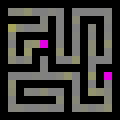

Maze-Large (59x59) - FLOPs/step: 81.7M

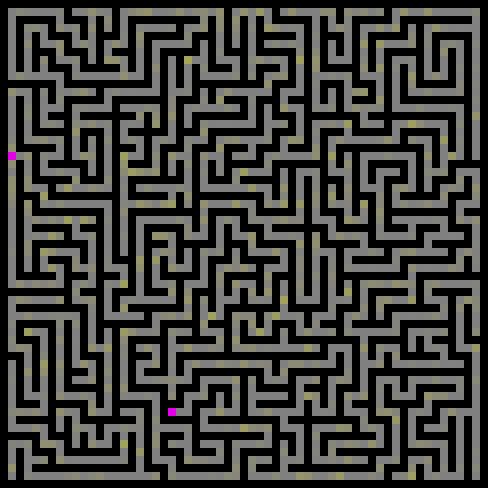

In [30]:
#@title Example rollout on Maze-OOD
import mediapy as media

exp_name = "mood"

# Update config to match the experiment
update_config(**configs[exp_name])

# Set Random Key
key = jr.PRNGKey(42)
sample_idx = 0

for difficulty, iter_n, step_t, title, fps in zip([13, 59], [100, 1000], [1, 1], ["Maze-Small (13x13)", "Maze-Large (59x59)"], [20,20]):

  input_mask = dsets[exp_name][difficulty]["input_masks"][sample_idx]
  target_grid = dsets[exp_name][difficulty]["target_grids"][sample_idx]

  # Initialize NCA State
  x0 = init_state(jr.PRNGKey(0), input_mask, target_grid, params[exp_name]["input_embed"])

  # NCA Rollout
  k1, key = jr.split(key)
  xs = nca_rollout(params[exp_name], x0, k1, input_mask, iter_n, return_full=True, sg_at_idx=-1)
  _ , logits, _ = nca_pred(params[exp_name], jnp.concatenate([x0[None],xs], axis=0))

  # FLOPS estimation
  single_step_flops = get_jax_flops_cpu(nca_step, params[exp_name], x0, key, input_mask)

  # Visualize Rollout
  media.show_video([arr_to_img(input_mask, logits[t], target_grid, dset_name=exp_name, zoom_r=8) for t in range(0,iter_n,step_t)], title=title + f" - FLOPs/step: {format_large_number(single_step_flops)}", fps=fps, codec="gif")

Maze-Hard - FLOPs/step: 76.3M

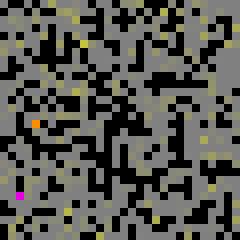

In [31]:
#@title Example rollout on Maze-Hard
import mediapy as media

exp_name = "mhard"

# Update config to match the experiment
update_config(**configs[exp_name])

# Set Random Key
key = jr.PRNGKey(42)

# Sample (input, output)
difficulty = "hard"
iter_n = 100
sample_idx = 0

input_mask = dsets[exp_name][difficulty]["input_masks"][sample_idx]
target_grid = dsets[exp_name][difficulty]["target_grids"][sample_idx]

# Initialize NCA State
x0 = init_state(jr.PRNGKey(0), input_mask, target_grid, params[exp_name]["input_embed"])

# NCA Rollout
k1, key = jr.split(key)
xs = nca_rollout(params[exp_name], x0, k1, input_mask, iter_n, return_full=True, sg_at_idx=-1)
temp1 , preds, temp2 = nca_pred(params[exp_name], jnp.concatenate([x0[None],xs], axis=0))

# FLOPS estimation
single_step_flops = get_jax_flops_cpu(nca_step, params[exp_name], x0, key, input_mask)

# Visualize Rollout
media.show_video([arr_to_img(input_mask, preds[t], target_grid, dset_name=exp_name, zoom_r=8) for t in range(len(preds))], title="Maze-Hard" + f" - FLOPs/step: {format_large_number(single_step_flops)}", fps=3, codec="gif")


Sudoku ID (47 cells to fill) - FLOPs/step: 45.5M

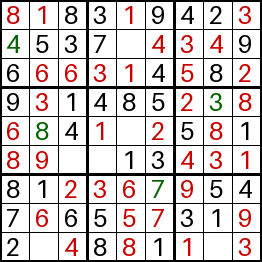

Sudoku OOD (55 cells to fill) - FLOPs/step: 45.5M

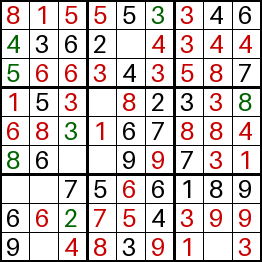

In [32]:
#@title Example rollout on Sudoku-OOD
import mediapy as media

exp_name = "sood"

# Update config to match the experiment
update_config(**configs[exp_name])

# Set Random Key
key = jr.PRNGKey(42)
sample_idx = 0
iter_n = 100
step_t = 1
fps = 3

for difficulty, title in zip([47, 55], ["Sudoku ID (47 cells to fill)", "Sudoku OOD (55 cells to fill)"]):

  input_mask = dsets[exp_name][difficulty]["input_masks"][sample_idx]
  target_grid = dsets[exp_name][difficulty]["target_grids"][sample_idx]

  # Initialize NCA State
  x0 = init_state(jr.PRNGKey(0), input_mask, target_grid, params[exp_name]["input_embed"])

  # NCA Rollout
  k1, key = jr.split(key)
  xs = nca_rollout(params[exp_name], x0, k1, input_mask, iter_n, return_full=True, sg_at_idx=-1)
  _ , logits, _ = nca_pred(params[exp_name], jnp.concatenate([x0[None],xs], axis=0))

  # FLOPS estimation
  single_step_flops = get_jax_flops_cpu(nca_step, params[exp_name], x0, key, input_mask)

  # Visualize Rollout
  media.show_video([arr_to_img(input_mask, logits[t], target_grid, dset_name=exp_name) for t in range(0,iter_n,step_t)], title=title + f" - FLOPs/step: {format_large_number(single_step_flops)}", fps=fps, codec="gif")


Sudoku-Extreme (diff 1-2) - FLOPs/step: 181.3M

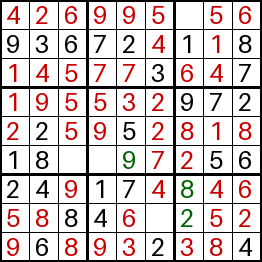

In [33]:
#@title Example rollout on Sudoku-Extreme
import mediapy as media

exp_name = "sext"

# Update config to match the experiment
update_config(**configs[exp_name])

# Set Random Key
key = jr.PRNGKey(42)

# Sample (input, output)
difficulty = "1-2-a"
iter_n = 256
sample_idx = 0

input_mask = dsets[exp_name][difficulty]["input_masks"][sample_idx]
target_grid = dsets[exp_name][difficulty]["target_grids"][sample_idx]

# Initialize NCA State
x0 = init_state(jr.PRNGKey(0), input_mask, target_grid, params[exp_name]["input_embed"])

# NCA Rollout
k1, key = jr.split(key)
xs = nca_rollout(params[exp_name], x0, k1, input_mask, iter_n, return_full=True, sg_at_idx=-1)
temp1 , preds, temp2 = nca_pred(params[exp_name], jnp.concatenate([x0[None],xs], axis=0))

# FLOPS estimation
single_step_flops = get_jax_flops_cpu(nca_step, params[exp_name], x0, key, input_mask)

# Visualize Rollout
media.show_video([arr_to_img(input_mask, preds[t], target_grid, dset_name=exp_name) for t in range(len(preds))], title=f"Sudoku-Extreme (diff {difficulty[:-2]})"+ f" - FLOPs/step: {format_large_number(single_step_flops)}", fps=3, codec="gif")
